# Visual Evaluation Notebook

This notebook is dedicated to **visual evaluation result presentation** and reads CSV files directly from `results/`.
It provides an integrated workflow for configuration-level comparison, task-level comparison, Pareto analysis, acceptance-rate analysis, speed distribution analysis, and consolidated exports.

## 1) Environment Setup

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
project_root = cwd
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src").exists() and (candidate / "results").exists():
        project_root = candidate
        break

src_dir = str(project_root / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print(f"Project root: {project_root}")
print(f"Results dir exists: {(project_root / 'results').exists()}")

Project root: C:\Working\speculative-decoding-main-v6
Results dir exists: True


## 2) Load Unified Visual Evaluation Backend

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from visual_eval_backend import (
    load_visual_evaluation,
    export_summary_tables,
    export_all_figures,
    plot_speedup_by_config,
    plot_pareto_speedup_vs_disagreement,
    plot_acceptance_heatmap,
    plot_task_speedup_heatmap,
    plot_speedup_distribution,
    plot_latency_gain_vs_acceptance,
)

results_dir = project_root / 'results'
bundle = load_visual_evaluation(results_dir)

print(f'Discovered CSV files: {len(bundle.discovered_files)}')
print(f'Baseline rows: {len(bundle.baseline_df)}')
print(f'Spec rows: {len(bundle.spec_df)}')
print(f'Paired rows: {len(bundle.merged_df)}')

Discovered CSV files: 14
Baseline rows: 2000
Spec rows: 12000
Paired rows: 12000


## 3) Summary Tables

In [3]:
if bundle.run_summary.empty:
    print('No speculative summary data found in results/.')
else:
    print('Run-level summary (sorted by speedup_mean):')
    display(bundle.run_summary)

if bundle.task_summary.empty:
    print('No task-level summary data found in results/.')
else:
    print('Task-level summary:')
    display(bundle.task_summary)

Run-level summary (sorted by speedup_mean):


,config,draft,k,regime,n_samples,n_tasks,latency_mean_s,baseline_latency_mean_s,speedup_mean,speedup_median,...,speedup_p90,ttft_mean_ms,tpot_mean_ms,tokens_per_sec_mean,baseline_tokens_per_sec_mean,alpha_mean,B_eff_mean,disagreement_rate,output_length_ratio_mean,disagreement_rate_pct
0,0.5B_k8_deterministic,0.5B,8,deterministic,1000,3,9.836499,16.849968,1.750575,1.715098,...,2.318079,184.18308,81.91358,12.94241,7.39218,0.360116,2.67776,0.829,1.0,82.9
1,1.5B_k8_deterministic,1.5B,8,deterministic,1000,3,9.746184,16.849968,1.731526,1.726268,...,2.251460,182.12442,82.66866,12.80021,7.39218,0.392401,2.92331,0.847,1.0,84.7
2,0.5B_k4_deterministic,0.5B,4,deterministic,1000,3,10.171830,16.849968,1.673549,1.665430,...,2.014449,182.72402,81.64416,12.36766,7.39218,0.430551,1.67238,0.846,1.0,84.6
3,1.5B_k4_deterministic,1.5B,4,deterministic,1000,3,10.209868,16.849968,1.649842,1.644270,...,1.954156,183.41951,82.88827,12.19312,7.39218,0.461965,1.79840,0.845,1.0,84.5
4,1.5B_k8_stochastic,1.5B,8,stochastic,1000,3,10.151628,16.460780,1.617556,1.609356,...,2.072760,184.21202,85.99794,12.26898,7.58588,0.380045,2.84463,0.921,1.0,92.1
5,0.5B_k8_stochastic,0.5B,8,stochastic,1000,3,10.206075,16.460780,1.614693,1.601236,...,2.115995,188.41717,86.43450,12.25392,7.58588,0.351643,2.63073,0.933,1.0,93.3
6,1.5B_k4_stochastic,1.5B,4,stochastic,1000,3,10.410613,16.460780,1.596029,1.589411,...,1.886972,182.27686,83.42893,12.10437,7.58588,0.453968,1.76739,0.922,1.0,92.2
7,0.5B_k16_deterministic,0.5B,16,deterministic,1000,3,11.518287,16.849968,1.586706,1.505066,...,2.316204,185.77177,97.14221,11.73622,7.39218,0.273617,3.78975,0.844,1.0,84.4
8,0.5B_k4_stochastic,0.5B,4,stochastic,1000,3,10.480748,16.460780,1.582284,1.571910,...,1.912699,183.68694,84.16545,11.99967,7.58588,0.419227,1.62668,0.930,1.0,93.0
9,1.5B_k16_deterministic,1.5B,16,deterministic,1000,3,11.257242,16.849968,1.568373,1.471890,...,2.294674,186.14140,97.53561,11.59683,7.39218,0.307801,4.27882,0.834,1.0,83.4


Task-level summary:


,config,draft,k,regime,task,n_samples,speedup_mean,speedup_median,latency_mean_s,baseline_latency_mean_s,alpha_mean,B_eff_mean,disagreement_rate,output_length_ratio_mean,disagreement_rate_pct
0,1.5B_k8_deterministic,1.5B,8,deterministic,cnndm,200,1.561532,1.534568,14.382761,22.092737,0.324622,2.540250,1.000000,1.0,100.000000
1,1.5B_k4_deterministic,1.5B,4,deterministic,cnndm,200,1.558460,1.542029,14.281119,22.092737,0.410103,1.627200,0.990000,1.0,99.000000
2,0.5B_k4_deterministic,0.5B,4,deterministic,cnndm,200,1.535683,1.509989,14.511480,22.092737,0.358586,1.421600,0.995000,1.0,99.500000
3,1.5B_k4_stochastic,1.5B,4,stochastic,cnndm,200,1.511076,1.494570,14.521902,21.813582,0.395187,1.567850,1.000000,1.0,100.000000
4,0.5B_k4_stochastic,0.5B,4,stochastic,cnndm,200,1.477989,1.463356,14.852170,21.813582,0.352097,1.396150,1.000000,1.0,100.000000
5,1.5B_k8_stochastic,1.5B,8,stochastic,cnndm,200,1.466786,1.442571,15.086800,21.813582,0.311043,2.433650,1.000000,1.0,100.000000
6,0.5B_k8_deterministic,0.5B,8,deterministic,cnndm,200,1.459069,1.414627,15.455000,22.092737,0.265153,2.077750,0.995000,1.0,99.500000
7,0.5B_k8_stochastic,0.5B,8,stochastic,cnndm,200,1.414945,1.402363,15.676018,21.813582,0.267912,2.101850,1.000000,1.0,100.000000
8,1.5B_k16_deterministic,1.5B,16,deterministic,cnndm,200,1.245963,1.201591,18.450117,22.092737,0.217997,3.336600,0.995000,1.0,99.500000
9,1.5B_k16_stochastic,1.5B,16,stochastic,cnndm,200,1.184425,1.144371,19.071472,21.813582,0.206623,3.153400,1.000000,1.0,100.000000


## 4) Core Visualizations

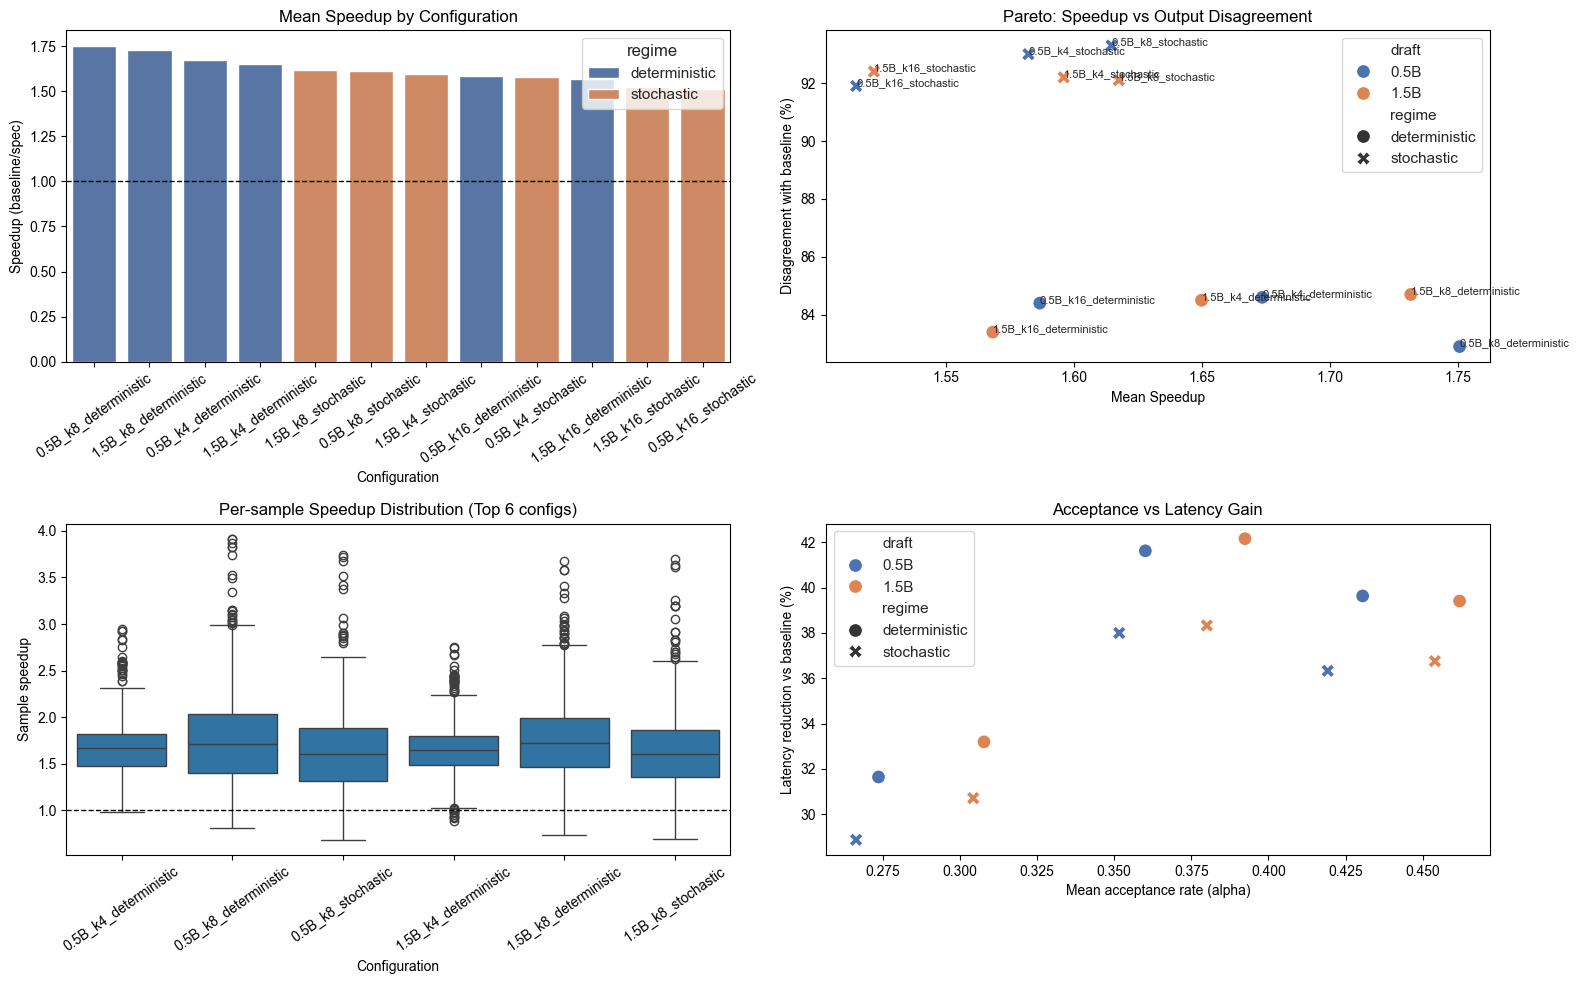

In [4]:
if bundle.run_summary.empty or bundle.merged_df.empty:
    print('Insufficient data for plotting. Ensure baseline_*.csv and spec_*.csv exist in results/.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plot_speedup_by_config(bundle.run_summary, ax=axes[0, 0])
    plot_pareto_speedup_vs_disagreement(bundle.run_summary, ax=axes[0, 1])
    plot_speedup_distribution(bundle.merged_df, top_configs=6, ax=axes[1, 0])
    plot_latency_gain_vs_acceptance(bundle.run_summary, ax=axes[1, 1])
    fig.tight_layout()
    plt.show()

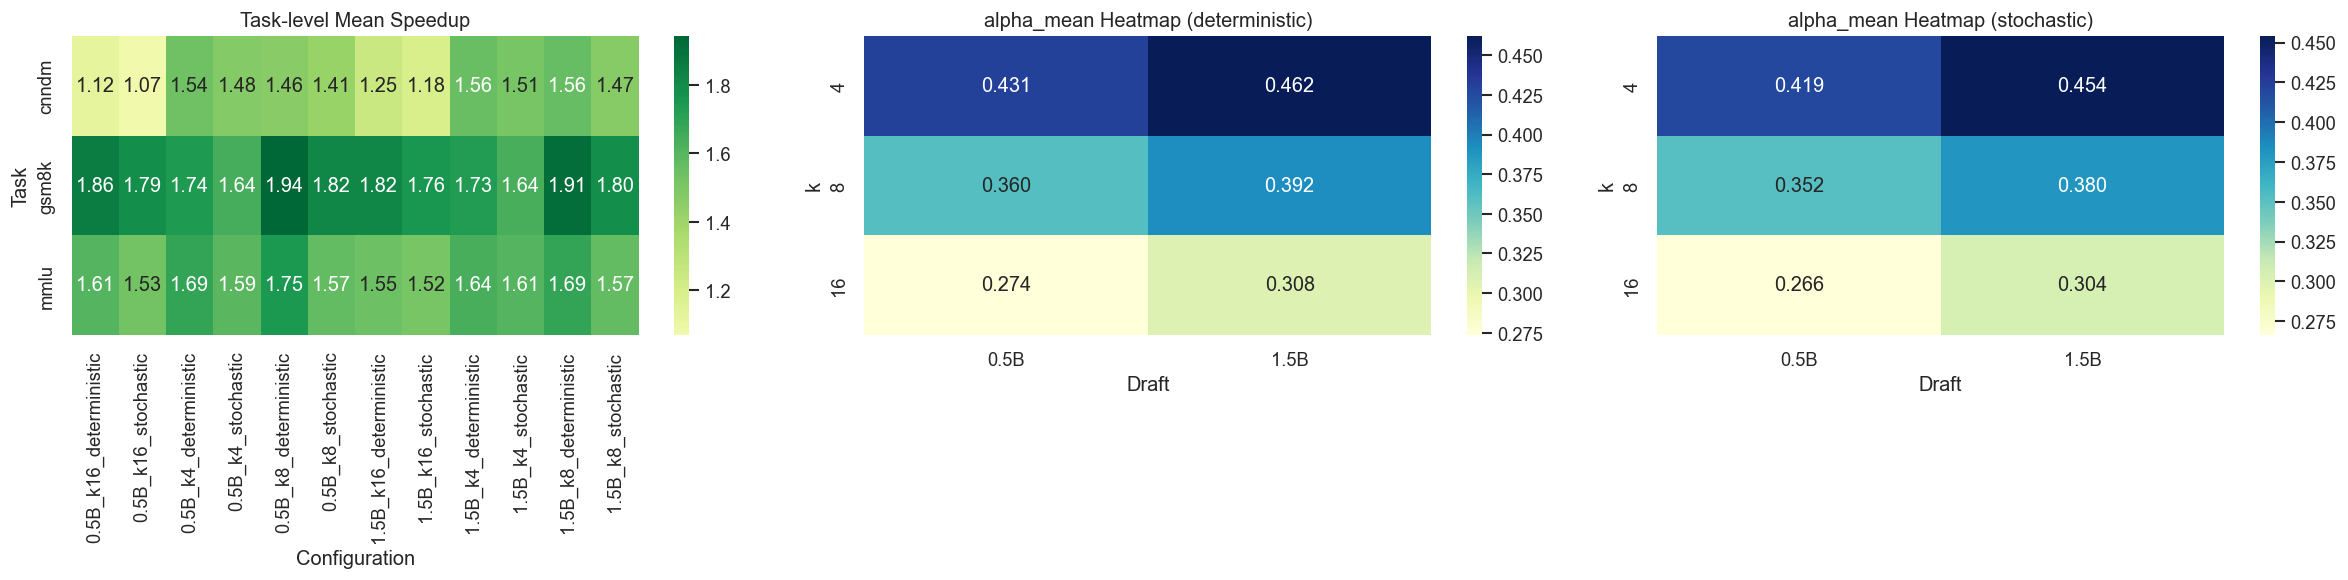

In [5]:
if bundle.run_summary.empty or bundle.task_summary.empty:
    print('Insufficient summary data for heatmaps.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    plot_task_speedup_heatmap(bundle.task_summary, ax=axes[0])

    regimes = list(bundle.run_summary['regime'].dropna().unique())
    if 'deterministic' in regimes:
        plot_acceptance_heatmap(bundle.run_summary, regime='deterministic', metric='alpha_mean', ax=axes[1])
    else:
        axes[1].set_axis_off()
        axes[1].set_title('No deterministic data')

    if 'stochastic' in regimes:
        plot_acceptance_heatmap(bundle.run_summary, regime='stochastic', metric='alpha_mean', ax=axes[2])
    else:
        axes[2].set_axis_off()
        axes[2].set_title('No stochastic data')

    fig.tight_layout()
    plt.show()

## 5) Export Tables and Figures

In [6]:
export_dir = results_dir / 'visual_eval'
export_dir.mkdir(parents=True, exist_ok=True)

table_paths = export_summary_tables(bundle, export_dir)
print('Exported tables:')
for name, p in table_paths.items():
    print(f'  {name}: {p}')

if bundle.run_summary.empty or bundle.merged_df.empty:
    print('Skipped figure export due to missing plotting data.')
else:
    fig_paths = export_all_figures(bundle, export_dir)
    print('Exported figures:')
    for name, p in fig_paths.items():
        print(f'  {name}: {p}')

Exported tables:
  run_summary: C:\Working\speculative-decoding-main-v6\results\visual_eval\run_summary.csv
  task_summary: C:\Working\speculative-decoding-main-v6\results\visual_eval\task_summary.csv
  pairwise_sample_metrics: C:\Working\speculative-decoding-main-v6\results\visual_eval\pairwise_sample_metrics.csv
Exported figures:
  speedup_by_config: C:\Working\speculative-decoding-main-v6\results\visual_eval\speedup_by_config.png
  pareto_speedup_vs_disagreement: C:\Working\speculative-decoding-main-v6\results\visual_eval\pareto_speedup_vs_disagreement.png
  acceptance_heatmaps: C:\Working\speculative-decoding-main-v6\results\visual_eval\acceptance_heatmaps.png
  task_speedup_heatmap: C:\Working\speculative-decoding-main-v6\results\visual_eval\task_speedup_heatmap.png
  speedup_distribution: C:\Working\speculative-decoding-main-v6\results\visual_eval\speedup_distribution.png
  latency_gain_vs_acceptance: C:\Working\speculative-decoding-main-v6\results\visual_eval\latency_gain_vs_acc

## 6) Quick Interpretation Helper

Recommended reading order:
1. Check `speedup_mean` and `disagreement_rate_pct` in `run_summary`.
2. In the Pareto chart, identify configurations with high speedup and low disagreement.
3. In the task heatmap, check for task-level regressions (for example, unstable speedup on specific tasks).